In [1]:
!pip install pandas numpy matplotlib seaborn gensim scikit-learn sentence-transformers umap-learn spacy tqdm
# !python -m spacy download es_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.0 MB/s eta 0:00:00


In [2]:
# -*- coding: utf-8 -*-
"""
Notebook: Análisis temporal de títulos del BOE (1995-2025)
Incluye:
 - Preprocesamiento en español (spaCy)
 - LDA por quinquenio
 - (Opcional) LdaSeqModel si quieres hacer DTM temporal fino
 - Embeddings con sentence-transformers
 - MMD (RBF) para medir drift entre quinquenios
 - Visualizaciones: stacked area, UMAP, MMD curve, frecuencias de palabras
"""

import os
import re
import itertools
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# NLP
import spacy

# Gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel
try:
    from gensim.models.ldaseqmodel import LdaSeqModel
    has_ldaseq = True
except Exception:
    has_ldaseq = False

# Embeddings & dimensionality reduction
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics.pairwise import cosine_similarity
import umap.umap_ as umap
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
# 0. CARGA DE DATOS
# -----------------------------------------------------------
df = pd.read_csv('dataset_universidades_procesado.csv')

# Asegurar columnas
if 'Fecha_Publicacion' not in df.columns or 'Titulo_Semantico' not in df.columns:
    raise ValueError("El CSV debe tener las columnas 'Fecha_Publicacion' y 'Titulo_Semantico'")

df['Fecha_Publicacion'] = pd.to_datetime(df['Fecha_Publicacion'], errors='coerce')
df = df.dropna(subset=['Fecha_Publicacion']).sort_values('Fecha_Publicacion').reset_index(drop=True)

print("Dimensiones:", df.shape)
print("Rango temporal:", df['Fecha_Publicacion'].min(), "-", df['Fecha_Publicacion'].max())


Dimensiones: (162574, 14)
Rango temporal: 1995-01-02 00:00:00 - 2024-01-30 00:00:00


In [7]:
# 1. PREPROCESAMIENTO (spaCy - español)
# -----------------------------------------------------------
# Cargar spaCy español
try:
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
except Exception:
    # Intentar descargar si no está presente
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "spacy", "download", "es_core_news_sm"])
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])

# Añadir lista de stopwords adicional (si quieres)
extra_stopwords = set([
    'artículo', 'real', 'decreto', 'ley', 'orden', 'resolución', 'ministro', 'ministra', 'universidad', 'don', 'doña', 'profesor', 'profesora', 'titular', 'catedrático',
    'universitario', 'universitaria', 'facultad', 'escuela', 'nombrar', 'nombramiento', 'plaza', 'cuerpo', 'docente', 'funcionario',
    'anuncio', 'extravio', 'título', 'publicar', 'publicación', 'convocatoria',
    'procedimiento', 'adjudicación', 'suministro', 'contrato', 'expediente',
    'formalización', 'servicio', 'acceso', 'selectivo', 'escala', 'provisión',
    'puesto', 'recurso', 'resolución', 'disposición', 'boe', 'pdf', 'página',

    'rey', 'juan', 'carlos', 'maría', 'josé', 'manuel', 'área', 'enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre'
])

def preprocess_text_spacy(text):
    if not isinstance(text, str):
        text = ""
    # limpiamos primero
    text = text.strip()

    # Procesar con spaCy
    doc = nlp(text.lower())
    tokens = []
    for tok in doc:
        # descartamos puntuación, espacios, stopwords, y tokens muy cortos
        if tok.is_space or tok.is_punct or tok.is_stop:
            continue
        lemma = tok.lemma_.strip()
        if not lemma:
            continue
        if len(lemma) <= 2:
            continue
        if lemma in extra_stopwords:
            continue
        # eliminar caracteres que no sean letras o guion medio (opcional)
        if lemma and len(lemma) > 2:
            tokens.append(lemma)
    return tokens

# Aplicar preprocesamiento
tqdm.pandas(desc="Preprocesando textos")
df['processed_tokens'] = df['texto_lower'].progress_apply(preprocess_text_spacy)
df['processed_text'] = df['processed_tokens'].apply(lambda toks: " ".join(toks))

# Ejemplo
print("\nEjemplo:")
print("Original:", df['Titulo_Semantico'].iloc[0])
print("Procesado tokens:", df['processed_tokens'].iloc[0])


Preprocesando textos: 100%|██████████| 162574/162574 [10:20<00:00, 262.11it/s]



Ejemplo:
Original: Resolución de 30 de noviembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación, entre funcionarios de carrera, puesto vacante en esta Universidad.
Procesado tokens: ['resolucion', 'politecnico', 'madrid', 'convocar', 'libre', 'designacion', 'carrera', 'vacante']


In [8]:
# 2. BOLSA DE PALABRAS (CountVectorizer)
# ===========================================================
# Creamos lista de documentos limpios
documents = df['processed_text'].tolist()

# Vectorizador (bag of words)
tf_vectorizer = CountVectorizer(
    min_df=10,           # eliminar palabras muy raras (aparecen en < 4 documentos)
    max_df=0.001,         # eliminar palabras demasiado frecuentes (> 20% de documentos)
    lowercase=True,
    max_features=20000, # tamaño máximo del vocabulario
    token_pattern='[a-zA-Záéíóúñü]{3,}',  # palabras alfabéticas de al menos 3 letras
    analyzer='word'
)

# Ajustar y transformar
bag_of_words = tf_vectorizer.fit_transform(documents)
dictionary = tf_vectorizer.get_feature_names_out()
vocabulary = tf_vectorizer.vocabulary_

print("\nTamaño vocabulario tras filtros:", len(dictionary))
print("Dimensión matriz:", bag_of_words.shape)


Tamaño vocabulario tras filtros: 3546
Dimensión matriz: (162574, 3546)


In [9]:
# 3. ANÁLISIS BÁSICO DE VOCABULARIO
# ===========================================================
# Obtener las palabras más frecuentes
word_counts = np.asarray(bag_of_words.sum(axis=0)).ravel()
freq_df = pd.DataFrame({
    'palabra': dictionary,
    'frecuencia': word_counts
}).sort_values('frecuencia', ascending=False)

print("\nTop 20 palabras más frecuentes:")
print(freq_df.head(20))


Top 20 palabras más frecuentes:
              palabra  frecuencia
654      cartografico         216
3381              usc         216
199          anatomia         209
1453         forestal         197
1466    fotogrametria         197
316       asistencial         192
1072           dibujo         177
3235          tension         172
2561            penal         171
2584     personalidad         170
1384     farmacologia         168
459   biblioteconomia         168
922          corporal         165
680           catalán         164
1214       energetico         164
923       corporativo         162
193            amparo         162
1406           ferrer         162
989            cuenta         162
171            alumno         161



Quinquenios detectados: [np.int32(1995), np.int32(2000), np.int32(2005), np.int32(2010), np.int32(2015), np.int32(2020)]


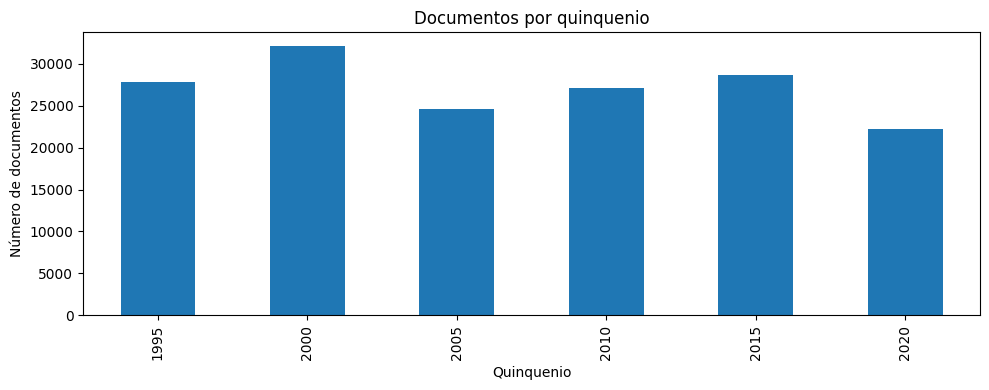

In [10]:
# 2. CREAR PERIODOS QUINQUENALES Y TIME SLICES
# -----------------------------------------------------------
# Periodo quinquenal: ej 1995 -> 1995, 1999 -> 1995, 2000 -> 2000, etc.
df['quinquenio'] = (df['Fecha_Publicacion'].dt.year // 5) * 5
quinquenios = sorted(df['quinquenio'].unique())
print("\nQuinquenios detectados:", quinquenios)

# Conteo por quinquenio
counts_q = df.groupby('quinquenio').size()
plt.figure(figsize=(10,4))
counts_q.plot(kind='bar')
plt.title('Documentos por quinquenio')
plt.xlabel('Quinquenio')
plt.ylabel('Número de documentos')
plt.tight_layout()
plt.show()

In [11]:
# 3. DICCIONARIO Y CORPUS (para LDA)
# -----------------------------------------------------------
dictionary = Dictionary(df['processed_tokens'])
# Filtramos: palabras que aparecen en menos de 5 documentos o en más del 50% de docs
dictionary.filter_extremes(no_below=5, no_above=0.3)
print("\nTamaño vocabulario tras filtros:", len(dictionary))

corpus = [dictionary.doc2bow(doc) for doc in df['processed_tokens']]


Tamaño vocabulario tras filtros: 7065


In [12]:
# 4. LDAº por quinquenio (modelo por cada periodo)
# -----------------------------------------------------------
# Parámetros LDA
num_topics = 8
passes = 20
random_state = 42

# Entrenar un LDA por quinquenio y guardar resultados
lda_per_q = {}
corpus_per_q = {}
dictionary_per_q = {}

for q in quinquenios:
    docs = df[df['quinquenio'] == q]['processed_tokens'].tolist()
    if len(docs) < 10:
        print(f"Quinquenio {q}: pocos documentos ({len(docs)}), se omite LDA")
        continue
    dict_q = Dictionary(docs)
    dict_q.filter_extremes(no_below=3, no_above=0.6)
    corpus_q = [dict_q.doc2bow(d) for d in docs]
    if len(dict_q) < 10:
        print(f"Quinquenio {q}: vocabulario muy pequeño ({len(dict_q)}), se omite")
        continue
    lda = LdaModel(corpus=corpus_q, id2word=dict_q, num_topics=num_topics,
                   passes=passes, random_state=random_state, chunksize=1000)
    lda_per_q[q] = lda
    corpus_per_q[q] = corpus_q
    dictionary_per_q[q] = dict_q
    print(f"Entrenado LDA para quinquenio {q} (docs={len(docs)}, vocab={len(dict_q)})")

# Función para obtener top-k palabras de cada tópico
def top_terms_lda(lda_model, k=10):
    topics = {}
    for tid in range(lda_model.num_topics):
        terms = lda_model.show_topic(tid, topn=k)
        topics[tid] = [t for t, w in terms]
    return topics

# Mostrar ejemplos
for q, lda in lda_per_q.items():
    print(f"\nQuinquenio {q} - top términos por tópico:")
    topics = top_terms_lda(lda, k=8)
    for tid, terms in topics.items():
        print(f" Tópico {tid}: {', '.join(terms)}")

Entrenado LDA para quinquenio 1995 (docs=27764, vocab=3433)
Entrenado LDA para quinquenio 2000 (docs=32136, vocab=3864)
Entrenado LDA para quinquenio 2005 (docs=24630, vocab=3086)
Entrenado LDA para quinquenio 2010 (docs=27071, vocab=3543)
Entrenado LDA para quinquenio 2015 (docs=28699, vocab=3526)
Entrenado LDA para quinquenio 2020 (docs=22274, vocab=1882)

Quinquenio 1995 - top términos por tópico:
 Tópico 0: autonomo, educacion, burgo, nacional, distancia, barcelona, valladolid, madrid
 Tópico 1: concurso, publico, contratacion, anunciar, adjudicacion, obra, abierto, politecnico
 Tópico 2: area, conocimiento, departamento, dona, catedratico, adscritar, aplicado, jose
 Tópico 3: estudio, plan, titulo, licenciado, publicacion, ordenar, conducente, ciencia
 Tópico 4: alcala, mancha, prueba, castilla, convocar, sistema, ingreso, libre
 Tópico 5: convocar, concurso, madrid, publico, complutense, citar, murcia, provision
 Tópico 6: area, conocimiento, dona, mario, catedratico, profesoro, 

---

### PRUEBAS ZERO-SHOT

In [ ]:
## ANALISIS DE FRECUENCIAS DE TÓPICOS Y TOKENS DE CARA A DEFINIR LOS TÓPICOS POR LOS QUE SE PREGUNTARÁ A LOS MODELOS ZERO-SHOT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.cluster import KMeans
import itertools

# 1. ANÁLISIS DE TÉRMINOS MÁS FRECUENTES
# -----------------------------------------------------------
print("=== ANÁLISIS DE TÉRMINOS MÁS FRECUENTES ===")

# Calcular frecuencias de todos los tokens
all_tokens = list(itertools.chain.from_iterable(df['processed_tokens']))
token_freq = Counter(all_tokens)

# Top 100 términos más frecuentes
top_100_terms = token_freq.most_common(100)
print(f"\nTop 50 términos más frecuentes (de {len(token_freq)} términos únicos):")
for i, (term, freq) in enumerate(top_100_terms[:50], 1):
    print(f"{i:2d}. {term:20s} - {freq:6d} apariciones")

# 2. ANÁLISIS DE BIGRAMAS (PAREJAS DE PALABRAS)
# -----------------------------------------------------------
print("\n=== ANÁLISIS DE BIGRAMAS ===")

# Generar bigramas
bigrams = []
for tokens in df['processed_tokens']:
    if len(tokens) >= 2:
        bigrams.extend([f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens)-1)])

bigram_freq = Counter(bigrams)
top_50_bigrams = bigram_freq.most_common(50)

print("Top 30 bigramas más frecuentes:")
for i, (bigram, freq) in enumerate(top_50_bigrams[:30], 1):
    print(f"{i:2d}. {bigram:30s} - {freq:6d} apariciones")

# 3. ANÁLISIS TF-IDF PARA TÉRMINOS MÁS ESPECÍFICOS
# -----------------------------------------------------------
print("\n=== ANÁLISIS TF-IDF (TÉRMINOS ESPECÍFICOS) ===")

# Convertir a texto para TF-IDF
documents = [' '.join(tokens) for tokens in df['processed_tokens']]

tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=10,
    max_df=0.4,
    stop_words=[]
)

tfidf_matrix = tfidf_vectorizer.fit_transform(documents)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Promedio de TF-IDF por término
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()

# Top términos por TF-IDF (más específicos)
tfidf_ranking = sorted(zip(feature_names, mean_tfidf),
                       key=lambda x: x[1], reverse=True)

print("Top 30 términos por TF-IDF (más específicos):")
for i, (term, score) in enumerate(tfidf_ranking[:30], 1):
    print(f"{i:2d}. {term:20s} - {score:.4f}")


# 7. ANÁLISIS DE TENDENCIAS TEMPORALES DE TÉRMINOS
# -----------------------------------------------------------
print("\n=== TENDENCIAS TEMPORALES DE TÉRMINOS PRINCIPALES ===")

# Analizar evolución de términos clave
key_terms = [term for term, freq in top_100_terms[:20]]

# Agrupar por quinquenio y contar términos
df['text_str'] = df['processed_tokens'].apply(lambda x: ' '.join(x))
term_trends = {}

for term in key_terms[:10]:  # Solo primeros 10 para no saturar
    trend = []
    for quinq in sorted(df['quinquenio'].unique()):
        mask = df['quinquenio'] == quinq
        docs_in_quinq = df[mask]['text_str']
        count = docs_in_quinq.str.contains(term, regex=False).sum()
        total_docs = mask.sum()
        trend.append((count / total_docs) * 100 if total_docs > 0 else 0)
    term_trends[term] = trend

# Mostrar tendencias
trend_df = pd.DataFrame(term_trends, index=sorted(df['quinquenio'].unique()))
print("\nEvolución porcentual de términos clave por quinquenio:")
print(trend_df.round(2))

# 8. RESUMEN PARA ZERO-SHOT
# -----------------------------------------------------------
print("\n" + "="*60)
print("RESUMEN PARA SELECCIÓN DE TEMÁTICAS ZERO-SHOT")
print("="*60)

print("\n🔍 TEMÁTICAS SUGERIDAS BASADAS EN EL ANÁLISIS:")

# Sugerencias basadas en términos frecuentes
thematic_suggestions = {
    'educación': ['educación', 'universidad', 'estudios', 'alumnos', 'docentes'],
    'salud': ['sanitario', 'salud', 'médico', 'hospital', 'enfermedad'],
    'economía': ['económico', 'presupuesto', 'financiero', 'empresa', 'mercado'],
    'empleo': ['trabajo', 'empleo', 'laboral', 'contrato', 'desempleo'],
    'administración': ['administrativo', 'procedimiento', 'registro', 'oficina', 'expediente'],
    'medio_ambiente': ['ambiental', 'medio', 'contaminación', 'naturaleza', 'sostenible'],
    'tecnología': ['tecnológico', 'digital', 'informático', 'internet', 'electrónico'],
    'transporte': ['transporte', 'vehículo', 'tráfico', 'carretera', 'movilidad'],
    'vivienda': ['vivienda', 'urbanístico', 'construcción', 'inmobiliario', 'alquiler'],
    'seguridad': ['seguridad', 'policial', 'delito', 'protección', 'emergencia']
}

# Verificar qué temáticas están presentes
print("\nTemáticas detectadas en el corpus:")
for theme, keywords in thematic_suggestions.items():
    matches = [kw for kw in keywords if kw in token_freq]
    if len(matches) >= 2:  # Al menos 2 palabras clave presentes
        print(f"✅ {theme.upper()}: {matches}")

print(f"\n📊 ESTADÍSTICAS CLAVE:")
print(f"   • Total documentos: {len(df):,}")
print(f"   • Vocabulario único: {len(token_freq):,} términos")
print(f"   • Términos más relevantes: {', '.join([term for term, freq in top_100_terms[:10]])}")
print(f"   • Bigramas clave: {', '.join([bigram for bigram, freq in top_50_bigrams[:5]])}")

print(f"\n💡 RECOMENDACIONES PARA ZERO-SHOT:")
print(f"   1. Usar las 8-12 temáticas más frecuentes identificadas")
print(f"   2. Incluir términos específicos de alto TF-IDF")
print(f"   3. Considerar la evolución temporal para temas emergentes")
print(f"   4. Validar con muestreo manual de documentos")

=== ANÁLISIS DE TÉRMINOS MÁS FRECUENTES ===

Top 50 términos más frecuentes (de 27971 términos únicos):
 1. extravío             -  41110 apariciones
 2. concurso             -  27465 apariciones
 3. madrid               -  23649 apariciones
 4. público              -  22785 apariciones
 5. conocimiento         -  21620 apariciones
 6. convocar             -  20407 apariciones
 7. estudio              -  18873 apariciones
 8. plan                 -  17853 apariciones
 9. educación            -  12098 apariciones
10. ciencia              -  12091 apariciones
11. politécnico          -  10709 apariciones
12. complutense          -  10326 apariciones
13. anunciar             -   8786 apariciones
14. departamento         -   8256 apariciones
15. valencia             -   8064 apariciones
16. autónomo             -   7683 apariciones
17. granada              -   7644 apariciones
18. contratación         -   7626 apariciones
19. profesoro            -   7624 apariciones
20. ingeniería        

---

Creamos un dataset con algunos de los titulares que tenemos y tres columnas vacías (una por cada modelo que vamos a utilizar), de cara a guardar los resultados de los diferentes modelos y poder compararlos para elegir el consenso de clasificación.

Vamos a realizar primero pequeñas pruebas de diferentes modelos para ver cúan parecidos son los resultados, y para ello cogemos 20 filas aleatorias de cada quinquenio.

In [ ]:
# cargamos el conjunto de datos preprocesado
import pandas as pd
df = pd.read_csv('dataset_preprocesado.csv')

In [ ]:
import pandas as pd

# Crear el nuevo dataset con 20 filas aleatorias por cada quinquenio
df_modelos_zeroshot = pd.DataFrame()

# Obtener los valores únicos de la columna "quinquenio"
quinquenios = df['quinquenio'].unique()

# Para cada quinquenio, seleccionar 20 filas aleatorias
for quinquenio in quinquenios:
    # Filtrar por quinquenio y seleccionar 20 filas aleatorias
    muestra_quinquenio = df[df['quinquenio'] == quinquenio].sample(n=20, random_state=42)

    # Crear el DataFrame temporal para este quinquenio
    df_temp = pd.DataFrame({
        'titulo': muestra_quinquenio['Titulo_Semantico'],
        'modelo1': '',
        'modelo2': '',
        'modelo3': '',
        'quinquenio': quinquenio  # Mantener la columna quinquenio para referencia
    })

    # Concatenar al DataFrame principal
    df_modelos_zeroshot = pd.concat([df_modelos_zeroshot, df_temp], ignore_index=True)

# Si no quieres incluir la columna quinquenio en el resultado final, puedes eliminarla:
# df_modelos_oneshot = df_modelos_oneshot.drop('quinquenio', axis=1)

# Guardar el nuevo dataset
# df_modelos_oneshot.to_csv('nuevo_dataset_titulos.csv', index=False, encoding='utf-8')

print("Nuevo dataset creado exitosamente!")
print(f"Dimensiones del nuevo dataset: {df_modelos_zeroshot.shape}")
print(f"Número de quinquenios únicos: {len(quinquenios)}")
print(f"Total de filas esperadas: {len(quinquenios) * 20}")
print("\nPrimeras 5 filas del nuevo dataset:")
print(df_modelos_zeroshot.head())

Nuevo dataset creado exitosamente!
Dimensiones del nuevo dataset: (120, 5)
Número de quinquenios únicos: 6
Total de filas esperadas: 120

Primeras 5 filas del nuevo dataset:
                                              titulo modelo1 modelo2 modelo3  \
0  Resolución de 15 de marzo de 1999, de la Unive...                           
1  Resolución de 21 de febrero de 1996, de la Uni...                           
2  Resolución de 29 de octubre de 1997, de la Uni...                           
3  Resolución de 23 de febrero de 1998, de la Uni...                           
4  Resolución de 8 de septiembre de 1999, de la U...                           

   quinquenio  
0        1995  
1        1995  
2        1995  
3        1995  
4        1995  


---

#### **ZERO-SHOT LEANING**

Estos modelos pueden clasificar texto en categorías que no han visto durante el entrenamiento, usando comprensión semántica y comparación entre el texto de entrada y las descripciones de las categorías.

![image.png](attachment:image.png)

2. **MoritzLaurer/deberta-v3-large-zeroshot-v1 (0.4B)** - Mayor tamaño, más downloads (2.31k), actualizado - Base técnica: DeBERTa v3 Large, arquitectura avanzada - Ideal para: Clasificación precisa de titulares complejos. (**MEJOR RENDIMIENTO**)

- Base Arquitectónica: DeBERTa v3 (Decoding-enhanced BERT with disentangled attention)
- Attention Desacoplado: Separa el contenido y la posición en los mecanismos de atención
- Matriz de Disentanglement: Mejor comprensión de relaciones sintácticas
- Enhanced Mask Decoder: Reconstrucción más precisa del texto
- Entrenamiento: Usa 1.5TB de datos multilingües

--

- Excelente captura de contexto corto (ideal para titulares)
- Mejor comprensión de estructuras gramaticales complejas
- Alta precisión en matices semánticos

In [ ]:
## PRUEBA EN TITULO INDIVIDUAL
#!pip install transformers[sentencepiece]
from transformers import pipeline
text = "Resolución de 30 de noviembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación, entre funcionarios de carrera, puesto vacante en esta Universidad."
# hypothesis_template = "This example is about {}"
classes_verbalized = ["salud", "economía", "empleo", "tecnología"]
zeroshot_classifier = pipeline("zero-shot-classification", model="MoritzLaurer/deberta-v3-large-zeroshot-v1")
output = zeroshot_classifier(text, classes_verbalized, multi_label=True)
print(output)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Device set to use cuda:0


{'sequence': 'Resolución de 30 de noviembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación, entre funcionarios de carrera, puesto vacante en esta Universidad.', 'labels': ['empleo', 'tecnología', 'economía', 'salud'], 'scores': [0.9959377646446228, 0.055157773196697235, 3.282725083408877e-05, 1.532610804133583e-05]}


In [ ]:
from transformers import pipeline
import torch

# Configuración de ejecución
device = 0 if torch.cuda.is_available() else -1
if torch.cuda.is_available():
    print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("❌ No hay GPU disponible")

# Inicializar el clasificador zero-shot
classes_verbalized = ["salud", "economía", "empleo", "tecnología"]
zeroshot_classifier = pipeline("zero-shot-classification", model="MoritzLaurer/deberta-v3-large-zeroshot-v1")

# Lista para almacenar los resultados
resultados_modelo2 = []

print("Analizando títulos con el modelo...")

# Procesar cada título
for i, titulo in enumerate(df_modelos_zeroshot['titulo']):
    try:
        # Clasificar el texto
        output = zeroshot_classifier(titulo, classes_verbalized, multi_label=True)

        # Crear diccionario con las clases y sus scores
        resultado_dict = {}
        for label, score in zip(output['labels'], output['scores']):
            resultado_dict[label] = float(score)

        # Guardar el diccionario como string
        resultados_modelo2.append(str(resultado_dict))

        if (i + 1) % 20 == 0:  # Mostrar progreso cada 10 títulos
            print(f"Procesados {i + 1}/{len(df_modelos_zeroshot)} títulos")

    except Exception as e:
        print(f"Error procesando título {i + 1}: {e}")
        resultados_modelo2.append("{}")  # Diccionario vacío en caso de error

# Asignar los resultados a la columna modelo1
df_modelos_zeroshot['modelo2'] = resultados_modelo2

# Guardar el dataset actualizado
# df_modelos_oneshot.to_csv('nuevo_dataset_titulos_analizado.csv', index=False, encoding='utf-8')

print(f"\nAnálisis completado!")
# print(f"Dataset guardado como 'nuevo_dataset_titulos_analizado.csv'")
print(f"Total de títulos procesados: {len(df_modelos_zeroshot)}")

# Mostrar algunos ejemplos
print("\nPrimeros 3 resultados:")
for i in range(min(3, len(df_modelos_zeroshot))):
    print(f"\nTítulo {i+1}: {df_modelos_zeroshot['titulo'].iloc[i][:100]}...")
    print(f"Modelo1: {df_modelos_zeroshot['modelo2'].iloc[i]}")

✅ GPU detectada: Tesla T4


Device set to use cuda:0


Analizando títulos con el modelo...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Procesados 20/120 títulos
Procesados 40/120 títulos
Procesados 60/120 títulos
Procesados 80/120 títulos
Procesados 100/120 títulos
Procesados 120/120 títulos

Análisis completado!
Total de títulos procesados: 120

Primeros 3 resultados:

Título 1: Resolución de 15 de marzo de 1999, de la Universidad Complutense de Madrid, por la que se nombra a d...
Modelo1: {'empleo': 0.029507363215088844, 'tecnología': 1.606160913070198e-05, 'economía': 1.3315580872585997e-05, 'salud': 1.3058037438895553e-05}

Título 2: Resolución de 21 de febrero de 1996, de la Universidad Politécnica de Madrid, por la que se corrige ...
Modelo1: {'tecnología': 0.028925716876983643, 'empleo': 7.003774226177484e-05, 'economía': 5.3910855058347806e-05, 'salud': 1.4567269317922182e-05}

Título 3: Resolución de 29 de octubre de 1997, de la Universidad de Lleida, por la que se publica la modificac...
Modelo1: {'empleo': 1.8271382941748016e-05, 'tecnología': 1.562838224344887e-05, 'economía': 1.5029679161671083e-05, 'salu

In [ ]:
# Guardamos resultados hasta ahora para posibles pérdidas
# df_modelos_zeroshot.to_csv('zeroshot_modelo1y2.csv', index=False, encoding='utf-8')

# Vistazo del dataset hasta ahora
df_modelos_zeroshot

,titulo,modelo1,modelo2,modelo3,quinquenio
0,"Resolución de 15 de marzo de 1999, de la Unive...",,"{'empleo': 0.029507363215088844, 'tecnología':...",,1995
1,"Resolución de 21 de febrero de 1996, de la Uni...",,"{'tecnología': 0.028925716876983643, 'empleo':...",,1995
2,"Resolución de 29 de octubre de 1997, de la Uni...",,"{'empleo': 1.8271382941748016e-05, 'tecnología...",,1995
3,"Resolución de 23 de febrero de 1998, de la Uni...",,"{'empleo': 0.9946877360343933, 'tecnología': 2...",,1995
4,"Resolución de 8 de septiembre de 1999, de la U...",,"{'salud': 0.0023051253519952297, 'empleo': 3.1...",,1995
...,...,...,...,...,...
115,Anuncio de la Facultad de Ciencias Sociales de...,,"{'empleo': 2.3552616767119616e-05, 'economía':...",,2020
116,"Resolución de 14 de mayo de 2021, de la Univer...",,"{'tecnología': 0.1175214871764183, 'empleo': 3...",,2020
117,Anuncio de la Escuela de Doctorado de la Unive...,,"{'empleo': 0.00045920847333036363, 'economía':...",,2020
118,Anuncio de la Facultad de Ciencias de la Salud...,,"{'salud': 0.7784810066223145, 'empleo': 3.6478...",,2020


1. **MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33 (0.2B)** - Especializado en 33 idiomas, muy popular (4.91k downloads) - Versátil para titulares en múltiples idiomas. (**MEJOR RENDIMIENTO**)

- Especialización Multilingüe
- Entrenamiento en 33 idiomas con datos balanceados
- Vocabulario multilingüe expandido
- Fine-tuning específico para clasificación zero-shot cross-lingual
- Mecanismo de alineación cross-lingual en el espacio semántico

--

- Transferencia cero entre idiomas
- Manejo de titulares con mezcla de idiomas
- Detección de referencias culturales específicas

In [ ]:
#!pip install transformers[sentencepiece]
from transformers import pipeline
text = "Resolución de 30 de noviembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación, entre funcionarios de carrera, puesto vacante en esta Universidad."
# hypothesis_template = "This example is about {}"
classes_verbalized = ["salud", "economía", "empleo", "tecnología"]
zeroshot_classifier = pipeline("zero-shot-classification", model="MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33")
output = zeroshot_classifier(text, classes_verbalized, multi_label=True)
print(output)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


{'sequence': 'Resolución de 30 de noviembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación, entre funcionarios de carrera, puesto vacante en esta Universidad.', 'labels': ['empleo', 'tecnología', 'economía', 'salud'], 'scores': [0.865053117275238, 0.08733005076646805, 0.00039666122756898403, 5.3491330618271604e-05]}


In [ ]:
#!pip install transformers[sentencepiece] torch
from transformers import pipeline
import torch

# En Colab con T4, esto debería mostrar "Tesla T4"
device = 0 if torch.cuda.is_available() else -1
if torch.cuda.is_available():
    print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("❌ No hay GPU disponible")

# Inicializar el clasificador zero-shot
classes_verbalized = ["salud", "economía", "empleo", "tecnología"]
zeroshot_classifier = pipeline("zero-shot-classification", model="MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33")

# Lista para almacenar los resultados
resultados_modelo1 = []

print("Analizando títulos con el modelo...")

# Procesar cada título
for i, titulo in enumerate(df_modelos_zeroshot['titulo']):
    try:
        # Clasificar el texto
        output = zeroshot_classifier(titulo, classes_verbalized, multi_label=True)

        # Crear diccionario con las clases y sus scores
        resultado_dict = {}
        for label, score in zip(output['labels'], output['scores']):
            resultado_dict[label] = float(score)

        # Guardar el diccionario como string
        resultados_modelo1.append(str(resultado_dict))

        if (i + 1) % 20 == 0:  # Mostrar progreso cada 10 títulos
            print(f"Procesados {i + 1}/{len(df_modelos_zeroshot)} títulos")

    except Exception as e:
        print(f"Error procesando título {i + 1}: {e}")
        resultados_modelo1.append("{}")  # Diccionario vacío en caso de error

# Asignar los resultados a la columna modelo1
df_modelos_zeroshot['modelo1'] = resultados_modelo1

# Guardar el dataset actualizado
# df_modelos_oneshot.to_csv('nuevo_dataset_titulos_analizado.csv', index=False, encoding='utf-8')

print(f"\nAnálisis completado!")
# print(f"Dataset guardado como 'nuevo_dataset_titulos_analizado.csv'")
print(f"Total de títulos procesados: {len(df_modelos_zeroshot)}")

# Mostrar algunos ejemplos
print("\nPrimeros 3 resultados:")
for i in range(min(3, len(df_modelos_zeroshot))):
    print(f"\nTítulo {i+1}: {df_modelos_zeroshot['titulo'].iloc[i][:100]}...")
    print(f"Modelo1: {df_modelos_zeroshot['modelo1'].iloc[i]}")

✅ GPU detectada: Tesla T4


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Analizando títulos con el modelo...
Procesados 20/120 títulos
Procesados 40/120 títulos
Procesados 60/120 títulos
Procesados 80/120 títulos
Procesados 100/120 títulos
Procesados 120/120 títulos

Análisis completado!
Total de títulos procesados: 120

Primeros 3 resultados:

Título 1: Resolución de 15 de marzo de 1999, de la Universidad Complutense de Madrid, por la que se nombra a d...
Modelo1: {'empleo': 0.0031115086749196053, 'economía': 0.0002642683102749288, 'tecnología': 0.00023413581948261708, 'salud': 8.51429722388275e-05}

Título 2: Resolución de 21 de febrero de 1996, de la Universidad Politécnica de Madrid, por la que se corrige ...
Modelo1: {'tecnología': 0.11225901544094086, 'empleo': 0.0064381021074950695, 'economía': 0.0051696584559977055, 'salud': 7.141901005525142e-05}

Título 3: Resolución de 29 de octubre de 1997, de la Universidad de Lleida, por la que se publica la modificac...
Modelo1: {'tecnología': 0.0005378764471970499, 'economía': 0.00012533750850707293, 'empleo

In [ ]:
# Guardamos resultados hasta ahora para posibles pérdidas
df_modelos_zeroshot.to_csv('zeroshot_modelo1y2.csv', index=False, encoding='utf-8')

# Vistazo del dataset hasta ahora
df_modelos_zeroshot

,titulo,modelo1,modelo2,modelo3,quinquenio
0,"Resolución de 15 de marzo de 1999, de la Unive...","{'empleo': 0.0031115086749196053, 'economía': ...","{'empleo': 0.029507363215088844, 'tecnología':...",,1995
1,"Resolución de 21 de febrero de 1996, de la Uni...","{'tecnología': 0.11225901544094086, 'empleo': ...","{'tecnología': 0.028925716876983643, 'empleo':...",,1995
2,"Resolución de 29 de octubre de 1997, de la Uni...","{'tecnología': 0.0005378764471970499, 'economí...","{'empleo': 1.8271382941748016e-05, 'tecnología...",,1995
3,"Resolución de 23 de febrero de 1998, de la Uni...","{'empleo': 0.8173558712005615, 'tecnología': 0...","{'empleo': 0.9946877360343933, 'tecnología': 2...",,1995
4,"Resolución de 8 de septiembre de 1999, de la U...","{'tecnología': 0.013902057893574238, 'economía...","{'salud': 0.0023051253519952297, 'empleo': 3.1...",,1995
...,...,...,...,...,...
115,Anuncio de la Facultad de Ciencias Sociales de...,"{'tecnología': 0.007260865997523069, 'empleo':...","{'empleo': 2.3552616767119616e-05, 'economía':...",,2020
116,"Resolución de 14 de mayo de 2021, de la Univer...","{'tecnología': 0.9958820939064026, 'economía':...","{'tecnología': 0.1175214871764183, 'empleo': 3...",,2020
117,Anuncio de la Escuela de Doctorado de la Unive...,"{'tecnología': 0.0005826939013786614, 'empleo'...","{'empleo': 0.00045920847333036363, 'economía':...",,2020
118,Anuncio de la Facultad de Ciencias de la Salud...,"{'salud': 0.7902067303657532, 'tecnología': 0....","{'salud': 0.7784810066223145, 'empleo': 3.6478...",,2020


3. **Recognai/zeroshot_selectra_medium (40.8M)** - Modelo mediano, buen equilibrio tamaño/rendimiento - Eficiente para aplicaciones con recursos limitados. (**LIGERO PERO EFECTIVO**)

- Arquitectura Selectra (Selective Transformer)
- Modelo más ligero pero optimizado para español
- Mecanismo de atención selectiva: Enfoca en palabras clave
- Fine-tuning con datos de noticias españolas
- Compresión de embeddings sin pérdida significativa de calidad

--

- Vocabulario enriquecido para español
- Especializado en lenguaje periodístico
- Inferencia rápida ideal para aplicaciones en tiempo real

In [ ]:
#!pip install transformers[sentencepiece]
from transformers import pipeline
text = "Resolución de 30 de noviembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación, entre funcionarios de carrera, puesto vacante en esta Universidad."
# hypothesis_template = "This example is about {}"
classes_verbalized = ["salud", "economía", "empleo", "tecnología"]
zeroshot_classifier = pipeline("zero-shot-classification", model="Recognai/zeroshot_selectra_medium")
output = zeroshot_classifier(text, classes_verbalized, multi_label=True)
print(output)

config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/163M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/337 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


{'sequence': 'Resolución de 30 de noviembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación, entre funcionarios de carrera, puesto vacante en esta Universidad.', 'labels': ['empleo', 'tecnología', 'salud', 'economía'], 'scores': [0.2198830544948578, 0.008107815869152546, 0.000945117324590683, 0.0008521088748238981]}


In [ ]:
#!pip install transformers[sentencepiece] torch
from transformers import pipeline
import torch

# En Colab con T4, esto debería mostrar "Tesla T4"
device = 0 if torch.cuda.is_available() else -1
if torch.cuda.is_available():
    print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("❌ No hay GPU disponible")

# Inicializar el clasificador zero-shot
classes_verbalized = ["salud", "economía", "empleo", "tecnología"]
zeroshot_classifier = pipeline("zero-shot-classification", model="Recognai/zeroshot_selectra_medium")

# Lista para almacenar los resultados
resultados_modelo3 = []

print("Analizando títulos con el modelo...")

# Procesar cada título
for i, titulo in enumerate(df_modelos_zeroshot['titulo']):
    try:
        # Clasificar el texto
        output = zeroshot_classifier(titulo, classes_verbalized, multi_label=True)

        # Crear diccionario con las clases y sus scores
        resultado_dict = {}
        for label, score in zip(output['labels'], output['scores']):
            resultado_dict[label] = float(score)

        # Guardar el diccionario como string
        resultados_modelo3.append(str(resultado_dict))

        if (i + 1) % 20 == 0:  # Mostrar progreso cada 10 títulos
            print(f"Procesados {i + 1}/{len(df_modelos_zeroshot)} títulos")

    except Exception as e:
        print(f"Error procesando título {i + 1}: {e}")
        resultados_modelo3.append("{}")  # Diccionario vacío en caso de error

# Asignar los resultados a la columna modelo1
df_modelos_zeroshot['modelo3'] = resultados_modelo3

# Guardar el dataset actualizado
# df_modelos_oneshot.to_csv('nuevo_dataset_titulos_analizado.csv', index=False, encoding='utf-8')

print(f"\nAnálisis completado!")
# print(f"Dataset guardado como 'nuevo_dataset_titulos_analizado.csv'")
print(f"Total de títulos procesados: {len(df_modelos_zeroshot)}")

# Mostrar algunos ejemplos
print("\nPrimeros 3 resultados:")
for i in range(min(3, len(df_modelos_zeroshot))):
    print(f"\nTítulo {i+1}: {df_modelos_zeroshot['titulo'].iloc[i][:100]}...")
    print(f"Modelo1: {df_modelos_zeroshot['modelo3'].iloc[i]}")

✅ GPU detectada: Tesla T4


Device set to use cuda:0


Analizando títulos con el modelo...
Procesados 20/120 títulos
Procesados 40/120 títulos
Procesados 60/120 títulos
Procesados 80/120 títulos
Procesados 100/120 títulos
Procesados 120/120 títulos

Análisis completado!
Total de títulos procesados: 120

Primeros 3 resultados:

Título 1: Resolución de 15 de marzo de 1999, de la Universidad Complutense de Madrid, por la que se nombra a d...
Modelo1: {'empleo': 0.0585443377494812, 'tecnología': 0.0010448237881064415, 'salud': 0.000986192375421524, 'economía': 0.0003174387093167752}

Título 2: Resolución de 21 de febrero de 1996, de la Universidad Politécnica de Madrid, por la que se corrige ...
Modelo1: {'empleo': 0.011649413034319878, 'tecnología': 0.007281607482582331, 'economía': 0.002663959749042988, 'salud': 0.0019535720348358154}

Título 3: Resolución de 29 de octubre de 1997, de la Universidad de Lleida, por la que se publica la modificac...
Modelo1: {'empleo': 0.019020594656467438, 'salud': 0.0016817476134747267, 'economía': 0.0015227

In [ ]:
# Guardamos resultados hasta ahora para posibles pérdidas
df_modelos_zeroshot.to_csv('zeroshot_completo.csv', index=False, encoding='utf-8')

# Vistazo del dataset hasta ahora
df_modelos_zeroshot

,titulo,modelo1,modelo2,modelo3,quinquenio
0,"Resolución de 15 de marzo de 1999, de la Unive...","{'empleo': 0.0031115086749196053, 'economía': ...","{'empleo': 0.029507363215088844, 'tecnología':...","{'empleo': 0.0585443377494812, 'tecnología': 0...",1995
1,"Resolución de 21 de febrero de 1996, de la Uni...","{'tecnología': 0.11225901544094086, 'empleo': ...","{'tecnología': 0.028925716876983643, 'empleo':...","{'empleo': 0.011649413034319878, 'tecnología':...",1995
2,"Resolución de 29 de octubre de 1997, de la Uni...","{'tecnología': 0.0005378764471970499, 'economí...","{'empleo': 1.8271382941748016e-05, 'tecnología...","{'empleo': 0.019020594656467438, 'salud': 0.00...",1995
3,"Resolución de 23 de febrero de 1998, de la Uni...","{'empleo': 0.8173558712005615, 'tecnología': 0...","{'empleo': 0.9946877360343933, 'tecnología': 2...","{'empleo': 0.01426334585994482, 'salud': 0.000...",1995
4,"Resolución de 8 de septiembre de 1999, de la U...","{'tecnología': 0.013902057893574238, 'economía...","{'salud': 0.0023051253519952297, 'empleo': 3.1...","{'salud': 0.028766833245754242, 'empleo': 0.02...",1995
...,...,...,...,...,...
115,Anuncio de la Facultad de Ciencias Sociales de...,"{'tecnología': 0.007260865997523069, 'empleo':...","{'empleo': 2.3552616767119616e-05, 'economía':...","{'empleo': 0.005037007853388786, 'economía': 0...",2020
116,"Resolución de 14 de mayo de 2021, de la Univer...","{'tecnología': 0.9958820939064026, 'economía':...","{'tecnología': 0.1175214871764183, 'empleo': 3...","{'empleo': 0.08399009704589844, 'tecnología': ...",2020
117,Anuncio de la Escuela de Doctorado de la Unive...,"{'tecnología': 0.0005826939013786614, 'empleo'...","{'empleo': 0.00045920847333036363, 'economía':...","{'empleo': 0.024808138608932495, 'tecnología':...",2020
118,Anuncio de la Facultad de Ciencias de la Salud...,"{'salud': 0.7902067303657532, 'tecnología': 0....","{'salud': 0.7784810066223145, 'empleo': 3.6478...","{'salud': 0.6960104703903198, 'empleo': 0.0318...",2020


---

Dividimos el conjunto en 3 partes iguales:

In [ ]:
import pandas as pd
import numpy as np

def dividir_datos_3_partes(data):
    """
    Divide un DataFrame en 3 partes iguales

    Args:
        data: DataFrame de pandas

    Returns:
        tuple: Tres DataFrames con el mismo número de filas
    """
    n = len(data)
    tamano_parte = n // 3

    # Calcular los índices de división
    idx1 = tamano_parte
    idx2 = 2 * tamano_parte

    # Dividir el DataFrame
    parte1 = data.iloc[:idx1]
    parte2 = data.iloc[idx1:idx2]
    parte3 = data.iloc[idx2:]

    return parte1, parte2, parte3


# Dividir los datos
data1, data2, data3 = dividir_datos_3_partes(df)

print(f"Parte 1: {len(data1)} filas")
print(f"Parte 2: {len(data2)} filas")
print(f"Parte 3: {len(data3)} filas")

Parte 1: 54192 filas
Parte 2: 54192 filas
Parte 3: 54192 filas


In [ ]:
data1.to_csv("df_primer_tercio.csv", index=False)
data2.to_csv("df_segundo_tercio.csv", index=False)
data3.to_csv("df_tercer_tercio.csv", index=False)

In [ ]:
data1.head()

,Unnamed: 0,ID_Disposicion,Fecha_Publicacion,Titulo_Semantico,Año_Semana,Año,Bloque_3dias,processed_tokens,processed_text,quinquenio
0,0,BOE-A-1995-26,1995-01-02,"Resolución de 30 de noviembre de 1994, de la U...",1995-01,1995,0,"['politécnico', 'madrid', 'convocar', 'libre',...",politécnico madrid convocar libre designación ...,1995
1,1,BOE-A-1995-27,1995-01-02,"Resolución de 12 de diciembre de 1994, de la U...",1995-01,1995,0,"['politécnico', 'madrid', 'convocar', 'libre',...",politécnico madrid convocar libre designación ...,1995
2,2,BOE-A-1995-77,1995-01-03,"Resolución de 28 de noviembre de 1994, de la U...",1995-01,1995,0,"['complutense', 'madrid', 'miembro', 'comisión...",complutense madrid miembro comisión juzgar con...,1995
3,3,BOE-A-1995-78,1995-01-03,"Resolución de 13 de diciembre de 1994, de la U...",1995-01,1995,0,"['jaén', 'público', 'composición', 'comisión',...",jaén público composición comisión resolver con...,1995
4,4,BOE-A-1995-205,1995-01-03,"Resolución de 12 de diciembre de 1994, de la U...",1995-01,1995,0,"['santiago', 'compostela', 'corregir', 'error'...",santiago compostela corregir error plan estudi...,1995


---

## EJECUCIÓN GRANDE.

Ejecución por partes y guardar resultados.

In [ ]:
import pandas as pd

df = pd.read_csv("df_primer_tercio.csv")  # CAMBIAR A TU NOMBRE DE ARCHIVO

In [ ]:
## MULTITHREADING PRIMER TERCIO MODELO

#!pip install transformers[sentencepiece] torch
from transformers import pipeline
import torch
from concurrent.futures import ThreadPoolExecutor
import numpy as np

# Configuración
device = 0 if torch.cuda.is_available() else -1
print(f"Usando dispositivo: {'GPU' if device == 0 else 'CPU'}")

classes_verbalized = ["salud", "economía", "empleo", "tecnología"]

# Cargar modelo
model_name = "MoritzLaurer/deberta-v3-large-zeroshot-v1"
zeroshot_classifier = pipeline(
    "zero-shot-classification",
    model=model_name,
    device=device
)

def procesar_lote_con_threads(titulos, batch_size=1000, num_threads=6):
    def procesar_batch(batch):
        try:
            outputs = zeroshot_classifier(batch, classes_verbalized, multi_label=True)
            resultados_batch = []
            for output in outputs:
                resultado_dict = {}
                for label, score in zip(output['labels'], output['scores']):
                    resultado_dict[label] = float(score)
                resultados_batch.append(str(resultado_dict))
            return resultados_batch
        except Exception as e:
            print(f"Error en batch: {e}")
            return ["{}"] * len(batch)

    resultados = []
    total_batches = (len(titulos) + batch_size - 1) // batch_size

    with ThreadPoolExecutor(max_workers=num_threads) as executor:
        futures = []

        # Programar todos los batches
        for i in range(0, len(titulos), batch_size):
            batch = titulos[i:i + batch_size]
            futures.append(executor.submit(procesar_batch, batch))

        # Recolectar resultados
        for i, future in enumerate(futures):
            try:
                resultados.extend(future.result())
            except:
                resultados.extend(["{}"] * min(batch_size, len(titulos) - i * batch_size))

            if (i + 1) % 10000 == 0:
                print(f"Procesados {min((i + 1) * batch_size, len(titulos))}/{len(titulos)} títulos")

    return resultados

print("Analizando títulos con procesamiento optimizado...")
resultados_modelo1 = procesar_lote_con_threads(
    df['Titulo_Semantico'].tolist(),
    batch_size=1000,
    num_threads=6
)
df['modelo_zeroshot'] = resultados_modelo1

print(f"\n✅ Análisis completado!")
print(f"Total de títulos procesados: {len(df)}")

Usando dispositivo: GPU


Device set to use cuda:0


Analizando títulos con procesamiento optimizado...


In [ ]:
df.to_csv("data_primer_tercio_zeroshot.csv")  # CAMBIAR INDICADOR DE TU CACHO EN EL NOMBRE